# L2. Qdrant Edge: An Embedded Memory Engine

Store personal notes as vectors in **Qdrant Edge**, an embedded engine with no server and no network. Then recall them by meaning, with the network switched off.

## 1. Ask before there's anything to remember

The model is already on the device. Watch what happens when we ask it something before storing a single memory.

In [1]:
import shutil
from pathlib import Path
from qdrant_edge import (
    EdgeShard, EdgeConfig, EdgeVectorParams, Distance,
    Query, QueryRequest,
)

SHARD_DIR = "./coffee_shard"
shutil.rmtree(SHARD_DIR, ignore_errors=True)
Path(SHARD_DIR).mkdir(parents=True, exist_ok=True)

config = EdgeConfig(
    vectors={
        "text": EdgeVectorParams(size=768, distance=Distance.Cosine),
    }
)
shard = EdgeShard.create(SHARD_DIR, config)
print("Empty shard created")

Empty shard created


In [2]:
from helper import embed_query

question = "where can I sit outside for a latte?"
hits = shard.query(
    QueryRequest(
        query=Query.Nearest(embed_query(question), using="text"),
        limit=3,
        with_payload=True,
    )
)
print("Q:", question)
print("Memories found:", len(hits))

Q: where can I sit outside for a latte?
Memories found: 0


## 2. The memories

In [3]:
import json

memories = json.load(open("../data/memories.json"))
notes = [m for m in memories if m["source_type"] == "text"]
for m in notes[:6]:
    print(f"[{m['category']:>8}] {m['note']}")
print("...")
print(len(notes), "text notes")

[    food] Great little coffee place on 5th with outdoor seating and fast wifi
[    work] Standup with Sarah moved to Thursday to review the Q3 roadmap
[ errands] Pick up dry cleaning before Friday, ticket is on the fridge
[    work] Idea: batch the weekly report so it drafts itself every Monday
[  social] Mum's new address is 14 Elm Court, buzzer 3
[shopping] Liked the black and white running shoes at the mall, about $45
...
20 text notes


## 3. Turn notes into vectors, on the device

In [4]:
from helper import embed_text

vectors = embed_text([m["note"] for m in notes])
print(f"Embedded {len(vectors)} notes with Nomic (768 dimensions)")

Embedded 20 notes with Nomic (768 dimensions)


## 4. Store the memories

In [5]:
from qdrant_edge import Point, UpdateOperation

points = [
    Point(id=m["id"], vector={"text": vectors[i]}, payload=m)
    for i, m in enumerate(notes)
]
shard.update(UpdateOperation.upsert_points(points))
shard.optimize()
print("Stored", shard.info().points_count, "memories")

Stored 20 memories


## 5. Ask again, now it remembers

In [6]:
hits = shard.query(
    QueryRequest(
        query=Query.Nearest(embed_query(question), using="text"),
        limit=3,
        with_payload=True,
    )
)
print("Q:", question, "\n")
for h in hits:
    print(f"  {h.score:.3f}  {h.payload['note']}")

Q: where can I sit outside for a latte? 

  0.653  Great little coffee place on 5th with outdoor seating and fast wifi
  0.590  Found a quiet cafe with good wifi to work from near the park
  0.511  Coffee run to the espresso bar near the office


## 6. The payoff: recall with the network off

In [7]:
from helper import no_network

question = "when is the standup with Sarah?"
with no_network():
    offline_hits = shard.query(
        QueryRequest(
            query=Query.Nearest(embed_query(question), using="text"),
            limit=1,
            with_payload=True,
        )
    )
print("Recall succeeded offline ->", offline_hits[0].payload["note"])

⚠ Python socket creation blocked for this cell
Recall succeeded offline -> Standup with Sarah moved to Thursday to review the Q3 roadmap


## 7. The payoff: how fast is local recall?

In [ ]:
import time
from helper import add_filler

add_filler(shard, "text", 5000, 768)
n = shard.info().points_count

query_vector = embed_query("coffee")
timings = []
for _ in range(200):
    t0 = time.perf_counter()
    shard.query(
        QueryRequest(
            query=Query.Nearest(query_vector, using="text"),
            limit=3,
            with_payload=True,
        )
    )
    timings.append((time.perf_counter() - t0) * 1000)
timings.sort()
median_ms = timings[len(timings) // 2]
print(f"Local recall median at {n:,} memories: {median_ms:.2f} ms "
      f"over 200 queries, on this CPU-only sandbox")

## 8. The payoff: does the memory survive a restart?

⚠ Python socket creation blocked for this cell


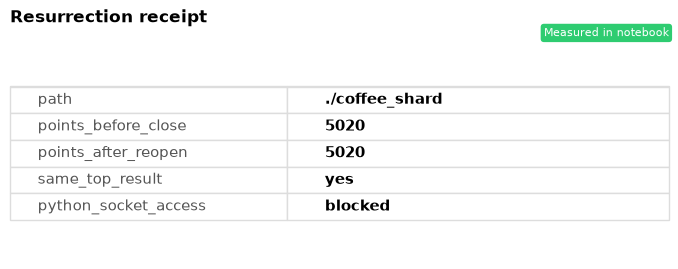

In [9]:
from helper import receipt_table

probe = QueryRequest(
    query=Query.Nearest(embed_query("coffee place outside"), using="text"),
    limit=1,
    with_payload=True,
)
before_top = shard.query(probe)[0]
before_count = shard.info().points_count

shard.close()

with no_network():
    reloaded = EdgeShard.load(SHARD_DIR)
    after_top = reloaded.query(probe)[0]

receipt_table([
    ("path", SHARD_DIR),
    ("points_before_close", before_count),
    ("points_after_reopen", reloaded.info().points_count),
    ("same_top_result", "yes" if before_top.id == after_top.id else "no"),
    ("python_socket_access", "blocked"),
])

In [10]:
import shutil
reloaded.close()
shutil.rmtree(SHARD_DIR, ignore_errors=True)
print("Cleaned up", SHARD_DIR)

Cleaned up ./coffee_shard
